In [1]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# 04_rq2_quant_analysis.py
# Purpose of Script: Assess Identification, Moderation Decisions and Automation
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initialization ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Google Drive
#~~~~~~~~~~~~~~~~~~~~~~~~~~
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Libraries
#~~~~~~~~~~~~~~~~~~~~~~~~~~
import numpy as np
import pandas as pd
import gc
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import PercentFormatter

In [3]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Print Versions
#~~~~~~~~~~~~~~~~~~~~~~~~~~
print(f"Numpy version = {np.__version__}")
print(f"Pandas version = {pd.__version__}")
print(f"DuckDB version = {duckdb.__version__}")
print(f"Seaborn version = {sns.__version__}")

Numpy version = 2.0.2
Pandas version = 2.2.2
DuckDB version = 1.3.2
Seaborn version = 0.13.2


In [4]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initiate Duck Connection
#~~~~~~~~~~~~~~~~~~~~~~~~~~
con = duckdb.connect()

#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Define Input/Output Paths
#~~~~~~~~~~~~~~~~~~~~~~~~~~
### Input
path_samp = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/01_final_data/03_samples/"
path_out = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/03_outputs/"
path_dup = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/01_final_data/05_duplicates/"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Quantitative Data ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import RQ2 Output from R
df = con.execute(f""" select * from '{path_samp}rq2_final.parquet' """).df()

# Filter Sample Only for Observation Period (Sample Collection Added Dates with 0 Entries)
df = df[df["date"] <= "2026-05-31 00:00:00"]

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Qualitative Data ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Tiktok
df_qual = con.execute(f""" select *
                           from read_parquet('{path_out}02_rq1_qual_14_tiktok_*.parquet')
                           """).df()

df_qual["platform"] = "tiktok"

# Format
df_qual["date"] = pd.to_datetime(df_qual["date"])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
# Cut Down Qual
df_qual_cut = df_qual[["platform","date","source"]]

# One Hot Encode Source
df_qual_cut = pd.get_dummies(df_qual_cut, columns=["source"],
                             prefix="source", dtype=int)

# Add Syn Flag
df_qual_cut["syn_flag"] = 1

# Aggregate
source_cols = [c for c in df_qual_cut.columns if c.startswith("source_")]

df_qual_cut_agg = (df_qual_cut.groupby(["platform","date","syn_flag"], as_index=False)
                   .agg(total_sor_entries=("platform","size"),
                        **{col: (col, "sum") for col in source_cols}))

# Rename Columns
df_qual_cut_agg = df_qual_cut_agg.rename(columns = {"source_v": "source_voluntary"})

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Duplicates ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_dup_facebook = con.execute(f""" select * from '{path_dup}08_rq2/facebook_rq2.parquet'""").df()
df_dup_instagram = con.execute(f""" select * from '{path_dup}08_rq2/instagram_rq2.parquet'""").df()

df_dup = pd.concat([df_dup_facebook, df_dup_instagram])

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Violating Content Source ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Quant ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Identify Relevant Columns
cols_to_extract = ['platform','date','syn_flag',
                   'total_sor_entries',
                   'source_a16',
                   'source_voluntary',
                   'source_other_notification',
                   'source_trusted_flagger']

# Source Quant
df_source = df[cols_to_extract].copy()

# Define Source Columns
source_cols_all = [c for c in df_source.columns if c.startswith("source")]
source_cols_dup = [c for c in df_dup.columns if c.startswith("source")]

# Define Base Columns
base_cols = ["platform","date","syn_flag","total_sor_entries"]

# Format Date Columns
df_source["date"] = pd.to_datetime(df_source["date"])
df_dup["date"] = pd.to_datetime(df_dup["date"])

# Join Duplicates
df_dup_join = df_dup[base_cols + source_cols_dup]
df_source = df_source.merge(df_dup_join, on =["platform","date","syn_flag"],
                            suffixes=("","_dup"), how="left")

# Fill NA
df_source = df_source.fillna(0)

# Minus Duplicates
df_source["total_sor_entries"] = (df_source["total_sor_entries"] - df_source["total_sor_entries_dup"])
df_source["source_voluntary"] = (df_source["source_voluntary"] - df_source["source_voluntary_dup"])

# Drop Duplicate Columns
df_source = df_source.drop(columns = ["total_sor_entries_dup","source_voluntary_dup"])

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Qual ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_qual_tiktok = df_qual_cut_agg.copy()

df_qual_tiktok = df_qual_tiktok.drop(columns="date")

# Aggregate Over All Days
df_qual_tiktok = (df_qual_tiktok.groupby(["platform","syn_flag"], as_index=False).sum())

In [ ]:
# Drop Date
df_source = df_source.drop(columns = "date")

# Aggregate over platform
groupby_cols = ["platform","syn_flag"]
df_source = (df_source.groupby(groupby_cols, as_index=False).sum())

# Add Quant/Qual Column
df_source["detected_via"] = "quant"
df_qual_tiktok["detected_via"] = "qual"

# Append
df_source = pd.concat([df_source, df_qual_tiktok])

# Fill NA
df_source = df_source.fillna(0)

In [ ]:
### Export
df_source.to_csv(f"{path_out}04_rq2_1_source_frequencies.csv")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Detection/Decision Automation ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Quant
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_det = df.copy()

cols_to_extract = ['platform','date','syn_flag',
                   'total_sor_entries',
                   'automated_detection_no',
                   'automated_detection_yes',
                   'automated_decision_not_automated',
                   'automated_decision_partially',
                   'automated_decision_fully']

df_det = df_det[cols_to_extract]

### Aggregate Data
df_det = (df_det.groupby(["platform", "syn_flag"], as_index=False)
          .agg({"total_sor_entries": "sum",
                "automated_detection_yes": "sum",
                "automated_detection_no": "sum",
                "automated_decision_not_automated": "sum",
                "automated_decision_partially": "sum",
                "automated_decision_fully": "sum"}))

### Calculate Relative %
aut_cols_all = [c for c in df_det.columns if c.startswith("auto")]

for col in aut_cols_all:
  df_det[f"{col}"] = (df_det[col]/df_det["total_sor_entries"] * 100)

## Fill NAs
df_det = df_det.fillna(0)

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Qual ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_qual_cut = df_qual[["platform","date","aut_det","aut_dec"]]

# One Hot Encode Automated Detection
df_qual_cut = pd.get_dummies(df_qual_cut, columns=["aut_det"],
                             prefix="automated_detection_", dtype=int)

# One Hot Encode Automated Decision
df_qual_cut = pd.get_dummies(df_qual_cut, columns=["aut_dec"],
                             prefix="automated_decision_", dtype=int)

# Add Syn Flag
df_qual_cut["syn_flag"] = 1

# Aggregate
source_cols = [c for c in df_qual_cut.columns if c.startswith("auto")]

df_qual_cut_agg = (df_qual_cut.groupby(["platform","date","syn_flag"], as_index=False)
                   .agg(total_sor_entries=("platform","size"),
                        **{col: (col, "sum") for col in source_cols}))

# Rename Columns
df_qual_cut_agg = df_qual_cut_agg.rename(columns = {"automated_detection__n": "automated_detection_no",
                                                    "automated_detection__y": "automated_detection_yes",
                                                    "automated_decision__f": "automated_decision_fully",
                                                    "automated_decision__p": "automated_decision_partially",
                                                    "automated_decision__n": "automated_decision_not_automated"})

### Aggregate Data
df_qual_cut_agg = (df_qual_cut_agg.groupby(["platform", "syn_flag"], as_index=False)
          .agg({"total_sor_entries": "sum",
                "automated_detection_yes": "sum",
                "automated_detection_no": "sum",
                "automated_decision_not_automated": "sum",
                "automated_decision_partially": "sum",
                "automated_decision_fully": "sum"}))

### Calculate Relative %
aut_cols_all = [c for c in df_qual_cut_agg.columns if c.startswith("auto")]

for col in aut_cols_all:
  df_qual_cut_agg[f"{col}"] = (df_qual_cut_agg[col]/df_qual_cut_agg["total_sor_entries"] * 100)

## Fill NAs
df_qual_cut_agg = df_qual_cut_agg.fillna(0)

In [ ]:
# Combine Quant & Qual
df_det["detected_via"] = "quant"
df_qual_cut_agg["detected_via"] = "qual"

df_det_all = pd.concat([df_det, df_qual_cut_agg])

In [ ]:
df_det_all

,platform,syn_flag,total_sor_entries,automated_detection_yes,automated_detection_no,automated_decision_not_automated,automated_decision_partially,automated_decision_fully,detected_via
0,facebook,0.0,5.970490e+08,96.867821,3.132179,3.132179,96.867821,0.000000,quant
1,facebook,1.0,4.112254e+07,89.823436,10.176564,10.176564,89.823436,0.000000,quant
2,instagram,0.0,1.495345e+08,96.487451,3.512549,3.512549,96.487451,0.000000,quant
3,instagram,1.0,1.619945e+07,90.623299,9.376701,9.376701,90.623299,0.000000,quant
4,snapchat,0.0,6.745969e+06,26.786812,73.213188,78.786117,0.000000,21.213883,quant
5,snapchat,1.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,quant
6,tiktok,0.0,1.314018e+09,98.239112,1.760888,5.606697,0.000268,94.393035,quant
7,tiktok,1.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,quant
8,whatsapp,0.0,3.349180e+05,46.022011,53.977989,99.990744,0.000000,0.009256,quant
9,whatsapp,1.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,quant


In [ ]:
### Export
df_det_all.to_csv(f"{path_out}04_rq2_2_automation_freq.csv")

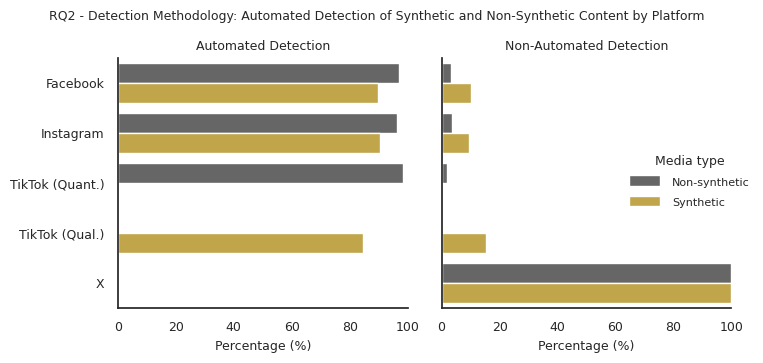

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Plot
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Filter For Platforms with Syn Media
df_plot = df_det_all[(df_det_all["platform"] == "facebook") |
                     (df_det_all["platform"] == "instagram") |
                     (df_det_all["platform"] == "x") |
                     (df_det_all["platform"] == "tiktok")]

# Remove 0 SOR entries
df_plot = df_plot[df_plot["total_sor_entries"] > 0]

# Fix Labels
df_plot["platform"] = df_plot["platform"].str.title()

# Remove where TikTok has NO Quant Synthetic
df_plot.loc[(df_plot["platform"] == "Tiktok") & (df_plot["syn_flag"] == 1),"platform"] = "TikTok (Qual.)"
df_plot.loc[(df_plot["platform"] == "Tiktok") & (df_plot["syn_flag"] == 0),"platform"] = "TikTok (Quant.)"

# Order by Platform
df_plot.sort_values("platform")


plot_long = df_plot.melt(id_vars=["platform", "syn_flag"],
                         value_vars=["automated_detection_yes",
                                     "automated_detection_no"],
                         var_name="Detection",
                         value_name="Percent")

# Format Labels
plot_long["Detection"] = plot_long["Detection"].replace({"automated_detection_yes": "Automated",
                                                         "automated_detection_no": "Not automated"})

plot_long["syn_flag"] = plot_long["syn_flag"].replace({0: "Non-synthetic", 1: "Synthetic"})

# Plot
sns.set_theme(style="whitegrid")

order = ["Facebook", "Instagram", "TikTok (Quant.)", "TikTok (Qual.)", "X"]

sns.set_style("white")
g = sns.catplot(data=plot_long, kind="bar", x="Percent", y="platform",
                hue="syn_flag", col="Detection", orient="h", height=3.8,
                aspect=0.8, errorbar=None, order=order,palette={"Non-synthetic": "#666666",
                                                                "Synthetic": "#D4AF37"})

g.fig.suptitle("RQ2 - Detection Methodology: Automated Detection of Synthetic and Non-Synthetic Content by Platform",
               fontsize=9, y=0.95)

g.set_titles("Automated", size=9)

for ax in g.axes.flat:
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

g.set_axis_labels("Percentage (%)", "", fontsize=9)
for ax in g.axes.flat:
    ax.xaxis.label.set_size(9)
    ax.yaxis.label.set_size(9)

g.set(xlim=(0, 100))
g.axes[0, 0].set_title("Automated Detection", fontsize=9)
g.axes[0, 1].set_title("Non-Automated Detection", fontsize=9)
g._legend.set_title("Media type")
g._legend.get_title().set_fontsize(9)


for text in g._legend.get_texts():
    text.set_fontsize(8)
plt.tight_layout()

## Export
plt.savefig(f"{path_out}04_rq2_3_automated_non_auto.pdf", format="pdf", dpi=600, bbox_inches="tight")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Moderation Outcomes ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Quant
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_mod = df.copy()

cols_to_extract_des = ['platform','date','syn_flag',
                       'total_sor_entries',
                       'content_decision_NA','content_removed', 'content_disabled',
                       'content_demoted', 'content_age_restricted',
                       'content_visibility_other',
                   'content_interaction_restricted','content_labelled',
                   'ar_and_cr_des_vis','ar_and_o_des_vis', 'cr_and_ar_des_vis',
                   'o_and_ar_des_vis', 'o_and_dem_des_vis','o_and_cr_des_vis',
                   'o_and_cr_and_ar_des_vis','ar_and_cr_and_o_des_vis', 'cr_and_o_des_vis']

cols_to_extract_mon = ['platform','date','syn_flag',
                       'total_sor_entries', 'monetary_decision_NA',
                       'monetary_account_suspension', 'monetary_account_termination']

cols_to_extract_acc = ['platform','date','syn_flag',
                       'total_sor_entries', 'account_decision_NA','account_suspended',
                       'account_terminated']

cols_to_extract_service = ['platform','date','syn_flag',
                           'total_sor_entries','service_decision_NA',
                           'service_partially_suspended','service_totally_suspended',
                           'service_partially_terminated', 'service_totally_terminated']

df_mod_des = df[cols_to_extract_des].copy()
df_mod_mon = df[cols_to_extract_mon].copy()
df_mod_acc = df[cols_to_extract_acc].copy()
df_mod_service = df[cols_to_extract_service].copy()

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Monetary Outcomes - Quant
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Cut-Down Duplicates
df_dup_mon = df_dup[["date","platform","syn_flag","total_sor_entries",
                     "monetary_decision_NA"]]

# Join Dupliates
df_mod_mon = df_mod_mon.merge(df_dup_mon, on=["date", "platform",
                                              "syn_flag"],
                              how="left", suffixes=("","_dup"))

# Fill NAs
df_mod_mon = df_mod_mon.fillna(0)

# Remove Duplicates
df_mod_mon["total_sor_entries"] = (df_mod_mon["total_sor_entries"] - df_mod_mon["total_sor_entries_dup"])
df_mod_mon["monetary_decision_NA"] = (df_mod_mon["monetary_decision_NA"] - df_mod_mon["monetary_decision_NA_dup"])

# Remove Dup Columns
df_mod_mon = df_mod_mon.drop(columns = ["monetary_decision_NA_dup",
                                        "total_sor_entries_dup"])

# Aggreagate Over all Dates
df_mod_mon = df_mod_mon.drop(columns = ["date"])
df_mod_mon = df_mod_mon.groupby(["platform","syn_flag"], as_index=False).sum()

# Generate quant/qual flag
df_mod_mon["detected_via"] = "quant"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Monetary Outcomes - TikTok Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_qual_cut = df_qual[["platform","date","des_mon"]]

# One Hot Encode Automated Detection
df_qual_cut = pd.get_dummies(df_qual_cut, columns=["des_mon"],
                             prefix="monetary_decision_", dtype=int)

# All Monetary Decisions are NA
df_qual_cut["monetary_decision_NA"] = 1

# Add Syn Flag
df_qual_cut["syn_flag"] = 1

# Add Total SORs Column
df_qual_cut["total_sor_entries"] = 1

# Sum
df_qual_cut = df_qual_cut.groupby(["platform","date","syn_flag"], as_index=False).sum()

# Remove Date
df_qual_cut = df_qual_cut.drop(columns = "date")

# Aggregate Again
df_qual_cut = (df_qual_cut.groupby(["platform","syn_flag"], as_index=False)
                                  .agg({"total_sor_entries": "sum",
                                        "monetary_decision_NA": "sum"}))

# Add Dectected Flag
df_qual_cut["detected_via"] = "qual"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Monetary Outcomes - Quant and Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_mod_mon = pd.concat([df_mod_mon, df_qual_cut])

# Fill NA
df_mod_mon = df_mod_mon.fillna(0)

# Set Order
df_mod_mon = df_mod_mon.sort_values(["platform","syn_flag"])

In [ ]:
### Export
df_mod_mon.to_csv(f"{path_out}04_rq2_4_monetary_outcomes.csv")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Account Outcomes - Quant
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Cut-Down Duplicates
df_dup_acc = df_dup[["date","platform","syn_flag",
                     "total_sor_entries",'account_decision_NA',
                     'account_suspended','account_terminated']]

# Join Dupliates
df_mod_acc = df_mod_acc.merge(df_dup_acc, on=["date", "platform",
                                              "syn_flag"],
                              how="left", suffixes=("","_dup"))

# Fill NAs
df_mod_acc = df_mod_acc.fillna(0)

# Remove Duplicates
df_mod_acc["total_sor_entries"] = (df_mod_acc["total_sor_entries"] - df_mod_acc["total_sor_entries_dup"])
df_mod_acc["account_decision_NA"] = (df_mod_acc["account_decision_NA"] - df_mod_acc["account_decision_NA_dup"])
df_mod_acc["account_suspended"] = (df_mod_acc["account_suspended"] -  df_mod_acc["account_suspended_dup"])
df_mod_acc["account_terminated"] = (df_mod_acc["account_terminated"] - df_mod_acc["account_terminated_dup"])

# Remove Dup Columns
df_mod_acc = df_mod_acc.drop(columns = ["account_decision_NA_dup",
                                        "account_suspended_dup",
                                        "account_terminated_dup",
                                        "total_sor_entries_dup"])

# Aggreagate Over all Dates
df_mod_acc = df_mod_acc.drop(columns = ["date"])
df_mod_acc = df_mod_acc.groupby(["platform","syn_flag"], as_index=False).sum()

# Generate quant/qual flag
df_mod_acc["detected_via"] = "quant"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Account Outcomes - TikTok Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_qual_cut = df_qual[["platform","date","des_acc"]]

# One Hot Encode Automated Detection
df_qual_cut = pd.get_dummies(df_qual_cut, columns=["des_acc"],
                             prefix="account_decision_", dtype=int)

# All Account Decisions are NA
df_qual_cut["account_decision_NA"] = 1

# Add Syn Flag
df_qual_cut["syn_flag"] = 1

# Add Total SORs Column
df_qual_cut["total_sor_entries"] = 1

# Sum
df_qual_cut = df_qual_cut.groupby(["platform","date","syn_flag"], as_index=False).sum()

# Remove Date
df_qual_cut = df_qual_cut.drop(columns = "date")

# Aggregate Again
df_qual_cut = (df_qual_cut.groupby(["platform","syn_flag"], as_index=False)
                                  .agg({"total_sor_entries": "sum",
                                        "account_decision_NA": "sum"}))

# Add Dectected Flag
df_qual_cut["detected_via"] = "qual"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Account Outcomes - Quant and Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_mod_acc = pd.concat([df_mod_acc, df_qual_cut])

# Fill NA
df_mod_acc = df_mod_acc.fillna(0)

# Set Order
df_mod_acc = df_mod_acc.sort_values(["platform","syn_flag"])

In [ ]:
### Export
df_mod_acc.to_csv(f"{path_out}04_rq2_5_account_outcomes.csv")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Service Outcomes - Quant
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Cut-Down Duplicates
df_dup_ser = df_dup[["date","platform","syn_flag",
                     "total_sor_entries",'service_decision_NA']]

# Join Dupliates
df_mod_service = df_mod_service.merge(df_dup_ser, on=["date", "platform",
                                              "syn_flag"],
                              how="left", suffixes=("","_dup"))

# Fill NAs
df_mod_service = df_mod_service.fillna(0)

# Remove Duplicates
df_mod_service["total_sor_entries"] = (df_mod_service["total_sor_entries"] - df_mod_service["total_sor_entries_dup"])
df_mod_service["service_decision_NA"] = (df_mod_service["service_decision_NA"] - df_mod_service["service_decision_NA_dup"])


# Remove Dup Columns
df_mod_service = df_mod_service.drop(columns = ["service_decision_NA_dup",
                                                "total_sor_entries_dup"])

# Aggreagate Over all Dates
df_mod_service = df_mod_service.drop(columns = ["date"])
df_mod_service = df_mod_service.groupby(["platform","syn_flag"], as_index=False).sum()

# Generate quant/qual flag
df_mod_service["detected_via"] = "quant"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Service Outcomes - TikTok Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_qual_cut = df_qual[["platform","date","des_prov"]]

# One Hot Encode Automated Detection
df_qual_cut = pd.get_dummies(df_qual_cut, columns=["des_prov"],
                             prefix="service_decision_", dtype=int)

# All Services Decisions are NA
df_qual_cut["service_decision_NA"] = 1

# Add Syn Flag
df_qual_cut["syn_flag"] = 1

# Add Total SORs Column
df_qual_cut["total_sor_entries"] = 1

# Sum
df_qual_cut = df_qual_cut.groupby(["platform","date","syn_flag"], as_index=False).sum()

# Remove Date
df_qual_cut = df_qual_cut.drop(columns = "date")

# Aggregate Again
df_qual_cut = (df_qual_cut.groupby(["platform","syn_flag"], as_index=False)
                                  .agg({"total_sor_entries": "sum",
                                        "service_decision_NA": "sum"}))

# Add Dectected Flag
df_qual_cut["detected_via"] = "qual"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Service Outcomes - Quant and Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_mod_service = pd.concat([df_mod_service, df_qual_cut])

# Fill NA
df_mod_service = df_mod_service.fillna(0)

# Set Order
df_mod_service = df_mod_service.sort_values(["platform","syn_flag"])

In [ ]:
### Export
df_mod_service.to_csv(f"{path_out}04_rq2_6_service_outcomes.csv")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Content Decision Outcomes - Quant
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_dup_des = df_dup[["platform","date","syn_flag",
                     "total_sor_entries", "content_decision_NA",
                     "content_removed","content_demoted"]]

# Join Dupliates
df_mod_des = df_mod_des.merge(df_dup_des, on=["date", "platform",
                                              "syn_flag"],
                              how="left", suffixes=("","_dup"))

# Fill NAs
df_mod_des = df_mod_des.fillna(0)

# Remove Duplicates
df_mod_des["total_sor_entries"] = (df_mod_des["total_sor_entries"] - df_mod_des["total_sor_entries_dup"])
df_mod_des["content_decision_NA"] = (df_mod_des["content_decision_NA"] - df_mod_des["content_decision_NA_dup"])
df_mod_des["content_removed"] = (df_mod_des["content_removed"] - df_mod_des["content_removed_dup"])
df_mod_des["content_demoted"] = (df_mod_des["content_demoted"] - df_mod_des["content_demoted_dup"])


# Remove Dup Columns
df_mod_des = df_mod_des.drop(columns = ["content_decision_NA_dup", "content_removed_dup",
                                        "content_demoted_dup", "total_sor_entries_dup"])

# Aggreagate Over all Dates
df_mod_des = df_mod_des.drop(columns = ["date"])
df_mod_des = df_mod_des.groupby(["platform","syn_flag"], as_index=False).sum()

# Generate quant/qual flag
df_mod_des["detected_via"] = "quant"


In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Decision Outcomes - TikTok Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_qual_cut = df_qual[["platform","date","des_vis"]]

# One Hot Encode Automated Detection
df_qual_cut = pd.get_dummies(df_qual_cut, columns=["des_vis"],
                             prefix="service_decision_", dtype=int)

# Replace Column Name Pattern
df_qual_cut.columns = df_qual_cut.columns.str.replace( r"^service_decision__(.+)$",
    r"\1_des_vis", regex=True)

# Replace Column Names with Convention
des_rename_map =  {"cr_des_vis": "content_removed",
                   "dis_des_vis": "content_disabled",
                   "dem_des_vis": "content_demoted",
                   "ar_des_vis": "content_age_restricted",
                   "ir_des_vis": "content_interaction_restricted",
                   "lab_des_vis": "content_labelled",
                   "o_des_vis": "content_visibility_other",
                   "NA_des_vis": "content_decision_NA"}

df_qual_cut = df_qual_cut.rename(columns = des_rename_map)

# Add Syn Flag
df_qual_cut["syn_flag"] = 1

# Add Total SORs Column
df_qual_cut["total_sor_entries"] = 1

# Sum
df_qual_cut = df_qual_cut.groupby(["platform","date","syn_flag"], as_index=False).sum()

# Remove Date
df_qual_cut = df_qual_cut.drop(columns = "date")

# Aggregate Again
df_qual_cut = (df_qual_cut.groupby(["platform","syn_flag"], as_index=False).sum())

# Add Dectected Flag
df_qual_cut["detected_via"] = "qual"

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Decision Outcomes - Quant and Qual
#~~~~~~~~~~~~~~~~~~~~~~~~~~
df_mod_des = pd.concat([df_mod_des, df_qual_cut])

# Fill NA
df_mod_des = df_mod_des.fillna(0)

# Set Order
df_mod_des = df_mod_des.sort_values(["platform","syn_flag"])

# Generate a Mixed Entry
### Note: Mixture contains age restricted, removed, other, demoted
df_mod_des["mixed"] = (df_mod_des["ar_and_cr_des_vis"] + df_mod_des["ar_and_o_des_vis"] +
                       df_mod_des["cr_and_ar_des_vis"] + df_mod_des["o_and_ar_des_vis"] +
                       df_mod_des["o_and_dem_des_vis"] + df_mod_des["o_and_cr_des_vis"] +
                       df_mod_des["o_and_cr_and_ar_des_vis"] + df_mod_des["ar_and_cr_and_o_des_vis"] +
                       df_mod_des["cr_and_o_des_vis"])

### Drop Additional Columns
df_mod_des = df_mod_des.drop(columns=["ar_and_cr_des_vis","ar_and_o_des_vis","cr_and_ar_des_vis",
                                      "o_and_ar_des_vis","o_and_dem_des_vis","o_and_cr_des_vis",
                                      "o_and_cr_and_ar_des_vis","ar_and_cr_and_o_des_vis",
                                      "cr_and_o_des_vis"])


In [ ]:
### Export
df_mod_des.to_csv(f"{path_out}04_rq2_7_decision_outcomes.csv")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Visualization
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Results Again
df_mod_mon = pd.read_csv(f"{path_out}04_rq2_4_monetary_outcomes.csv", index_col=0)
df_mod_ser = pd.read_csv(f"{path_out}04_rq2_6_service_outcomes.csv", index_col=0)
df_mod_acc = pd.read_csv(f"{path_out}04_rq2_5_account_outcomes.csv", index_col=0)
df_mod_des = pd.read_csv(f"{path_out}04_rq2_7_decision_outcomes.csv", index_col=0)

In [ ]:
# Define Order
platform_order = ["tiktok", "facebook", "instagram","youtube",
                  "snapchat","x","whatsapp"]

In [ ]:
# Format Data
#### Function: Alter Synthetic Flag
def alter_flag(df):
  df = df.copy()
  df["synthetic"] = df["syn_flag"].map({0: "(NS)", 1 : "(S)"})
  return(df)

In [ ]:
df_mod_mon = alter_flag(df_mod_mon)
df_mod_ser = alter_flag(df_mod_ser)
df_mod_acc = alter_flag(df_mod_acc)
df_mod_des = alter_flag(df_mod_des)

In [ ]:
# Convert to Relative %
def convert_perc(df):
  df = df.copy()
  cols_ignore = ["platform","syn_flag","total_sor_entries","detected_via","synthetic"]
  cols_convert = [c for c in df.columns if c not in cols_ignore]

  df[cols_convert] = df[cols_convert].div(df["total_sor_entries"].replace(0, np.nan), axis=0).mul(100)
  return df

In [ ]:
df_mod_mon = convert_perc(df_mod_mon)
df_mod_ser = convert_perc(df_mod_ser)
df_mod_acc = convert_perc(df_mod_acc)
df_mod_des = convert_perc(df_mod_des)

In [ ]:
# Merge Platform and Synthetic Column
def plat_perc(df):
  df = df.copy()
  df["label"] = (df["platform"].str.title() + " " + df["synthetic"])
  return(df)

In [ ]:
df_mod_mon = plat_perc(df_mod_mon)
df_mod_ser = plat_perc(df_mod_ser)
df_mod_acc = plat_perc(df_mod_acc)
df_mod_des = plat_perc(df_mod_des)

In [ ]:
# Prepare Data For Plotting - Monetary
df_mod_mon["platform"] = pd.Categorical(df_mod_mon["platform"], categories=platform_order,
                                        ordered=True)

df_mod_mon = df_mod_mon.sort_values(["platform", "syn_flag"], ascending=[False,True])

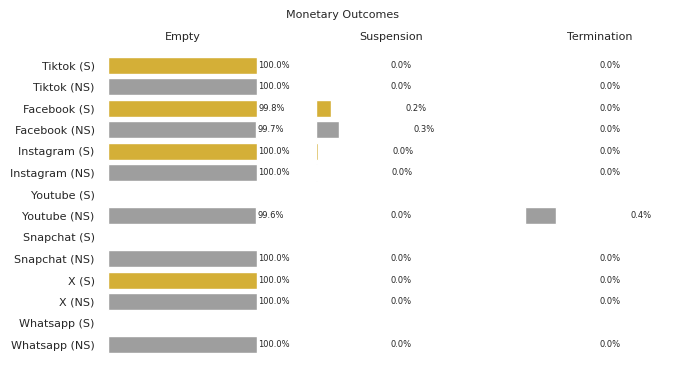

In [ ]:
# Mini Bar Charts Map - Monetary Decisions
# Set Fontsize
fontsize_fig = 8
fontsize_fig_perc = 6

colors = ["#D4AF37" if flag == 1 else "#9E9E9E"for flag in df_mod_mon["syn_flag"]]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7,4), sharey=True)

ax1.barh(y=df_mod_mon["label"], width=df_mod_mon["monetary_decision_NA"])

bars = ax1.barh(y=df_mod_mon["label"], width=df_mod_mon["monetary_decision_NA"],
        color = colors)

for bar, value in zip(bars, df_mod_mon["monetary_decision_NA"]):

    ax1.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax2.barh(y=df_mod_mon["label"], width=df_mod_mon["monetary_account_suspension"],
        color = colors)

for bar, value in zip(bars, df_mod_mon["monetary_account_suspension"]):

    ax2.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax3.barh(y=df_mod_mon["label"], width=df_mod_mon["monetary_account_termination"],
        color = colors)

for bar, value in zip(bars, df_mod_mon["monetary_account_termination"]):

    ax3.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

ax1.set_xlim(0,100)
for ax in [ax1, ax2, ax3]:
    ax.set_xticks([])
ax2.set_xlim(0,2)
ax3.set_xlim(0,2)

ax1.tick_params(axis='y', labelsize=fontsize_fig)
ax2.tick_params(axis='y', labelsize=fontsize_fig)
ax3.tick_params(axis='y', labelsize=fontsize_fig)

ax1.set_title("Empty", fontsize=fontsize_fig, pad=0)
ax2.set_title("Suspension", fontsize=fontsize_fig, pad=0)
ax3.set_title("Termination", fontsize=fontsize_fig, pad=0)

ax1.xaxis.set_major_formatter(PercentFormatter())
ax2.xaxis.set_major_formatter(PercentFormatter())
ax3.xaxis.set_major_formatter(PercentFormatter())

fig.suptitle("Monetary Outcomes", fontsize=fontsize_fig, y= 0.94)

plt.tight_layout(rect=[0, 0, 1, 1])

for spine in ax1.spines.values():
    spine.set_visible(False)

for spine in ax2.spines.values():
    spine.set_visible(False)

for spine in ax3.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(wspace=0.4)
plt.savefig(f"{path_out}04_rq2_8_monetary_outcomes_figure.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# Prepare Data For Plotting - Account
df_mod_acc["platform"] = pd.Categorical(df_mod_acc["platform"], categories=platform_order,
                                        ordered=True)

df_mod_acc = df_mod_acc.sort_values(["platform", "syn_flag"], ascending=[False,True])

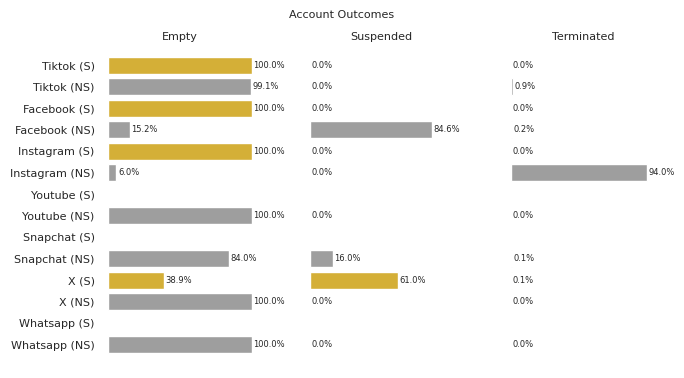

In [ ]:
# Mini Bar Charts Map - Account
# Set Fontsize
fontsize_fig = 8
fontsize_fig_perc = 6

colors = ["#D4AF37" if flag == 1 else "#9E9E9E"for flag in df_mod_acc["syn_flag"]]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7,4), sharey=True)

ax1.barh(y=df_mod_acc["label"], width=df_mod_acc["account_decision_NA"])

bars = ax1.barh(y=df_mod_acc["label"], width=df_mod_acc["account_decision_NA"],
        color = colors)

for bar, value in zip(bars, df_mod_acc["account_decision_NA"]):

    ax1.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax2.barh(y=df_mod_acc["label"], width=df_mod_acc["account_suspended"],
        color = colors)

for bar, value in zip(bars, df_mod_acc["account_suspended"]):

    ax2.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax3.barh(y=df_mod_acc["label"], width=df_mod_acc["account_terminated"],
        color = colors)

for bar, value in zip(bars, df_mod_acc["account_terminated"]):

    ax3.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

ax1.set_xlim(0,100)
for ax in [ax1, ax2, ax3]:
    ax.set_xticks([])
ax2.set_xlim(0,100)
ax3.set_xlim(0,100)

ax1.tick_params(axis='y', labelsize=fontsize_fig)
ax2.tick_params(axis='y', labelsize=fontsize_fig)
ax3.tick_params(axis='y', labelsize=fontsize_fig)

ax1.set_title("Empty", fontsize=fontsize_fig, pad=0)
ax2.set_title("Suspended", fontsize=fontsize_fig, pad=0)
ax3.set_title("Terminated", fontsize=fontsize_fig, pad=0)

ax1.xaxis.set_major_formatter(PercentFormatter())
ax2.xaxis.set_major_formatter(PercentFormatter())
ax3.xaxis.set_major_formatter(PercentFormatter())

fig.suptitle("Account Outcomes", fontsize=fontsize_fig, y= 0.94)

plt.tight_layout(rect=[0, 0, 1, 1])

for spine in ax1.spines.values():
    spine.set_visible(False)

for spine in ax2.spines.values():
    spine.set_visible(False)

for spine in ax3.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(wspace=0.4)
plt.savefig(f"{path_out}04_rq2_9_account_outcomes_figure.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# Prepare Data For Plotting - Service
df_mod_ser["platform"] = pd.Categorical(df_mod_ser["platform"], categories=platform_order,
                                        ordered=True)

df_mod_ser = df_mod_ser.sort_values(["platform", "syn_flag"], ascending=[False,True])

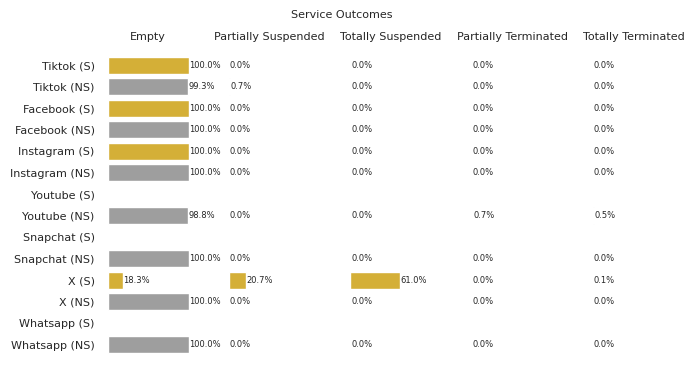

In [ ]:
# Mini Bar Charts Map - Service
# Set Fontsize
fontsize_fig = 8
fontsize_fig_perc = 6

colors = ["#D4AF37" if flag == 1 else "#9E9E9E"for flag in df_mod_ser["syn_flag"]]

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(7,4), sharey=True)

ax1.barh(y=df_mod_ser["label"], width=df_mod_ser["service_decision_NA"])
bars = ax1.barh(y=df_mod_ser["label"], width=df_mod_ser["service_decision_NA"],
        color = colors)

for bar, value in zip(bars, df_mod_ser["service_decision_NA"]):
    ax1.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax2.barh(y=df_mod_ser["label"], width=df_mod_ser["service_partially_suspended"],
        color = colors)
for bar, value in zip(bars, df_mod_ser["service_partially_suspended"]):
    ax2.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax3.barh(y=df_mod_ser["label"], width=df_mod_ser["service_totally_suspended"],
        color = colors)
for bar, value in zip(bars, df_mod_ser["service_totally_suspended"]):
    ax3.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax4.barh(y=df_mod_ser["label"], width=df_mod_ser["service_partially_terminated"],
        color = colors)
for bar, value in zip(bars, df_mod_ser["service_partially_terminated"]):
    ax4.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)


bars = ax5.barh(y=df_mod_ser["label"], width=df_mod_ser["service_totally_terminated"],
        color = colors)
for bar, value in zip(bars, df_mod_ser["service_totally_terminated"]):
    ax5.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)


ax1.set_xlim(0,100)
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_xticks([])
ax2.set_xlim(0,100)
ax3.set_xlim(0,100)
ax4.set_xlim(0,100)
ax5.set_xlim(0,100)

ax1.tick_params(axis='y', labelsize=fontsize_fig)
ax2.tick_params(axis='y', labelsize=fontsize_fig)
ax3.tick_params(axis='y', labelsize=fontsize_fig)
ax4.tick_params(axis='y', labelsize=fontsize_fig)
ax5.tick_params(axis='y', labelsize=fontsize_fig)

ax1.set_title("Empty", fontsize=fontsize_fig, pad=0)
ax2.set_title("Partially Suspended", fontsize=fontsize_fig, pad=0)
ax3.set_title("Totally Suspended", fontsize=fontsize_fig, pad=0)
ax4.set_title("Partially Terminated", fontsize=fontsize_fig, pad=0)
ax5.set_title("Totally Terminated", fontsize=fontsize_fig, pad=0)

ax1.xaxis.set_major_formatter(PercentFormatter())
ax2.xaxis.set_major_formatter(PercentFormatter())
ax3.xaxis.set_major_formatter(PercentFormatter())
ax4.xaxis.set_major_formatter(PercentFormatter())
ax5.xaxis.set_major_formatter(PercentFormatter())

fig.suptitle("Service Outcomes", fontsize=fontsize_fig, y= 0.94)

plt.tight_layout(rect=[0, 0, 1, 1])

for spine in ax1.spines.values():
    spine.set_visible(False)

for spine in ax2.spines.values():
    spine.set_visible(False)

for spine in ax3.spines.values():
    spine.set_visible(False)

for spine in ax4.spines.values():
    spine.set_visible(False)

for spine in ax5.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(wspace=0.5)
plt.savefig(f"{path_out}04_rq2_10_service_outcomes_figure.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# Prepare Data For Plotting - Content
df_mod_des["platform"] = pd.Categorical(df_mod_des["platform"], categories=platform_order,
                                        ordered=True)

df_mod_des = df_mod_des.sort_values(["platform", "syn_flag"], ascending=[False,True])

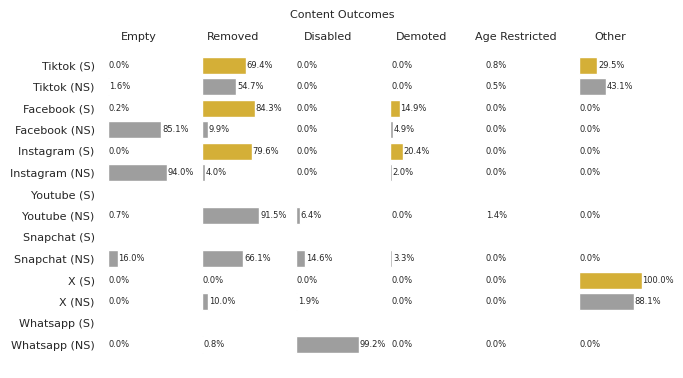

In [ ]:
fontsize_fig = 8
fontsize_fig_perc = 6

colors = ["#D4AF37" if flag == 1 else "#9E9E9E"for flag in df_mod_des["syn_flag"]]

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(1, 6, figsize=(7,4), sharey=True)

ax1.barh(y=df_mod_des["label"], width=df_mod_des["content_decision_NA"])
bars = ax1.barh(y=df_mod_des["label"], width=df_mod_des["content_decision_NA"],
        color = colors)

for bar, value in zip(bars, df_mod_des["content_decision_NA"]):
    ax1.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax2.barh(y=df_mod_des["label"], width=df_mod_des["content_removed"],
        color = colors)
for bar, value in zip(bars, df_mod_des["content_removed"]):
    ax2.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax3.barh(y=df_mod_des["label"], width=df_mod_des["content_disabled"],
        color = colors)
for bar, value in zip(bars, df_mod_des["content_disabled"]):
    ax3.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax4.barh(y=df_mod_des["label"], width=df_mod_des["content_demoted"],
        color = colors)
for bar, value in zip(bars, df_mod_des["content_demoted"]):
    ax4.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)


bars = ax5.barh(y=df_mod_des["label"], width=df_mod_des["content_age_restricted"],
        color = colors)
for bar, value in zip(bars, df_mod_des["content_age_restricted"]):
    ax5.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)

bars = ax6.barh(y=df_mod_des["label"], width=df_mod_des["content_visibility_other"],
        color = colors)
for bar, value in zip(bars, df_mod_des["content_visibility_other"]):
    ax6.text(value + 1, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%", va="center", fontsize=fontsize_fig_perc)


ax1.set_xlim(0,100)
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_xticks([])
ax2.set_xlim(0,100)
ax3.set_xlim(0,100)
ax4.set_xlim(0,100)
ax5.set_xlim(0,100)
ax6.set_xlim(0,100)

ax1.tick_params(axis='y', labelsize=fontsize_fig)
ax2.tick_params(axis='y', labelsize=fontsize_fig)
ax3.tick_params(axis='y', labelsize=fontsize_fig)
ax4.tick_params(axis='y', labelsize=fontsize_fig)
ax5.tick_params(axis='y', labelsize=fontsize_fig)
ax6.tick_params(axis='y', labelsize=fontsize_fig)

ax1.set_title("Empty", fontsize=fontsize_fig, pad=0)
ax2.set_title("Removed", fontsize=fontsize_fig, pad=0)
ax3.set_title("Disabled", fontsize=fontsize_fig, pad=0)
ax4.set_title("Demoted", fontsize=fontsize_fig, pad=0)
ax5.set_title("Age Restricted", fontsize=fontsize_fig, pad=0)
ax6.set_title("Other", fontsize=fontsize_fig, pad=0)

ax1.xaxis.set_major_formatter(PercentFormatter())
ax2.xaxis.set_major_formatter(PercentFormatter())
ax3.xaxis.set_major_formatter(PercentFormatter())
ax4.xaxis.set_major_formatter(PercentFormatter())
ax5.xaxis.set_major_formatter(PercentFormatter())
ax6.xaxis.set_major_formatter(PercentFormatter())

fig.suptitle("Content Outcomes", fontsize=fontsize_fig, y= 0.94)

plt.tight_layout(rect=[0, 0, 1, 1])

for spine in ax1.spines.values():
    spine.set_visible(False)

for spine in ax2.spines.values():
    spine.set_visible(False)

for spine in ax3.spines.values():
    spine.set_visible(False)

for spine in ax4.spines.values():
    spine.set_visible(False)

for spine in ax5.spines.values():
    spine.set_visible(False)

for spine in ax6.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(wspace=0.5)
plt.savefig(f"{path_out}04_rq2_11_content_outcomes_figure.png", dpi=600, bbox_inches="tight")
plt.show()